In [ ]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

con = psycopg2.connect(
    host=os.getenv("host"),
    port=os.getenv("port"),
    dbname=os.getenv("dbname"),
    user=os.getenv("user"),
    password=os.getenv("password")
)

df = pd.read_sql_query("""
                        SELECT t1.*, t2.btc_price
                        FROM gold.m2_global AS t1


                        LEFT JOIN gold.btc_dol AS t2
                        ON t1.yearmonth = t2.yearmonth 
                        """, con=con)

df = df.sort_values(by="yearmonth", ascending=True)

df["m2_global"] = pd.to_numeric(df["m2_global"])
df["btc_price"] = pd.to_numeric(df["btc_price"])
df["yearmonth"] = pd.to_datetime(df["yearmonth"])

C:\Users\kauan\AppData\Local\Temp\ipykernel_14552\2822191182.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


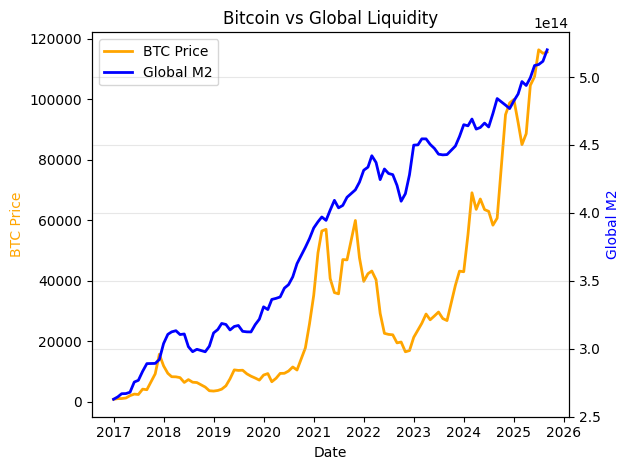

In [4]:
fig, ax1 = plt.subplots()

# Plot do BTC
line1, = ax1.plot(
    df["yearmonth"], 
    df["btc_price"], 
    color="orange", 
    linewidth=2,
    label="BTC Price"
)

ax1.set_ylabel("BTC Price", color="orange")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

#Plot do M2 global
line2, = ax2.plot(
    df["yearmonth"], 
    df["m2_global"], 
    color="blue", 
    linewidth=2,
    label="Global M2"
)

ax2.set_ylabel("Global M2", color="blue")

# Apenas janeiro de cada ano
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# legenda 
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Bitcoin vs Global Liquidity")
plt.grid(alpha=0.3)

fig.tight_layout()
plt.show()
